# Análisis Exploratorio de Datos (EDA) — Predicción Multiclase del Deterioro Cognitivo

Este notebook documenta de manera rigurosa el análisis exploratorio del conjunto de datos
utilizado para la clasificación multiclase del deterioro cognitivo, medido a través de la
escala GDS (*Global Deterioration Scale*) y sus cinco recodificaciones alternativas
(`GDS_R1` – `GDS_R5`).

El objetivo de esta fase es:
1. Verificar la **integridad** de los datos (dimensionalidad, valores nulos).
2. Cuantificar el **desbalance de clases** en las seis variables objetivo.
3. Seleccionar las **características más relevantes** mediante la prueba estadística χ² de Pearson,
   aplicada **antes** de cualquier técnica de remuestreo (SMOTE), garantizando así que el ranking
   refleje la dependencia estadística real entre los atributos y la variable objetivo.

---
## 1. Carga de Datos y Verificación de Dimensionalidad

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath('../src'))
from data_loader import load_raw_data

DATASET_FILEPATH = '../data/raw/15 atributos R0-R5.sav'
df = load_raw_data(DATASET_FILEPATH)

In [2]:
total_rows, total_cols = df.shape
print(f"Dimensionalidad del dataset: {total_rows} filas × {total_cols} columnas")
display(df.head())

Dimensionalidad del dataset: 1119 filas × 22 columnas


,ID,Día,Mes,Año,Estación,País,Ciudad,CalleLugar,NumeroPiso,Miguel2,...,Imperial2,A682,Caldera2,Copiapo2,GDS,GDS_R1,GDS_R2,GDS_R3,GDS_R4,GDS_R5
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,2.0,2.0
1,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0
4,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0


### 1.1 Verificación de Valores Nulos

In [3]:
null_count_per_column = df.isnull().sum()
total_null_count = null_count_per_column.sum()

print(f"Total de valores nulos en el dataset: {total_null_count}")
print(f"Verificación matemática: {total_rows} filas × {total_cols} columnas "
      f"= {total_rows * total_cols} celdas totales")
print(f"Celdas no nulas: {df.notna().sum().sum()}")
print(f"Proporción de nulos: {total_null_count}/{total_rows * total_cols} = "
      f"{total_null_count / (total_rows * total_cols) * 100:.4f}%")

Total de valores nulos en el dataset: 0
Verificación matemática: 1119 filas × 22 columnas = 24618 celdas totales
Celdas no nulas: 24618
Proporción de nulos: 0/24618 = 0.0000%


> **Conclusión de integridad:** El dataset no presenta **ningún valor nulo** en
> ninguna de sus variables. Esto garantiza que las posteriores etapas de
> modelado y validación cruzada podrán ejecutarse sin necesidad de imputación,
> lo que preserva la distribución original de los datos y elimina una fuente
> potencial de sesgo.

---
## 2. Análisis del Desbalance de Clases en las Seis Codificaciones GDS

La variable clínica objetivo admite **seis codificaciones** distintas
(`GDS`, `GDS_R1`, `GDS_R2`, `GDS_R3`, `GDS_R4`, `GDS_R5`), cada una de las cuales
asigna los pacientes a diferentes niveles de gravedad del deterioro cognitivo.
A continuación se presenta la distribución de pacientes por nivel para cada
codificación.

In [4]:
TARGET_COLUMNS = ['GDS', 'GDS_R1', 'GDS_R2', 'GDS_R3', 'GDS_R4', 'GDS_R5']

for target in TARGET_COLUMNS:
    counts = df[target].value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)
    summary = pd.DataFrame({
        'Cantidad': counts,
        'Porcentaje (%)': percentages
    })
    summary.index.name = target
    print(f"\n{'='*55}")
    print(f"  Distribución de clases para: {target}")
    print(f"{'='*55}")
    display(summary)


  Distribución de clases para: GDS


,Cantidad,Porcentaje (%)
GDS,,
1.0,149,13.32
2.0,500,44.68
3.0,298,26.63
4.0,108,9.65
5.0,42,3.75
6.0,20,1.79
7.0,2,0.18



  Distribución de clases para: GDS_R1


,Cantidad,Porcentaje (%)
GDS_R1,,
1.0,947,84.63
2.0,150,13.40
3.0,22,1.97



  Distribución de clases para: GDS_R2


...

,Cantidad,Porcentaje (%)
GDS_R3,,
1.0,947,84.63
3.0,172,15.37



  Distribución de clases para: GDS_R4


,Cantidad,Porcentaje (%)
GDS_R4,,
1.0,149,13.32
2.0,906,80.97
3.0,64,5.72



  Distribución de clases para: GDS_R5


,Cantidad,Porcentaje (%)
GDS_R5,,
1.0,149,13.32
2.0,798,71.31
3.0,172,15.37


### 2.1 Gráfico Comparativo de Barras Agrupadas

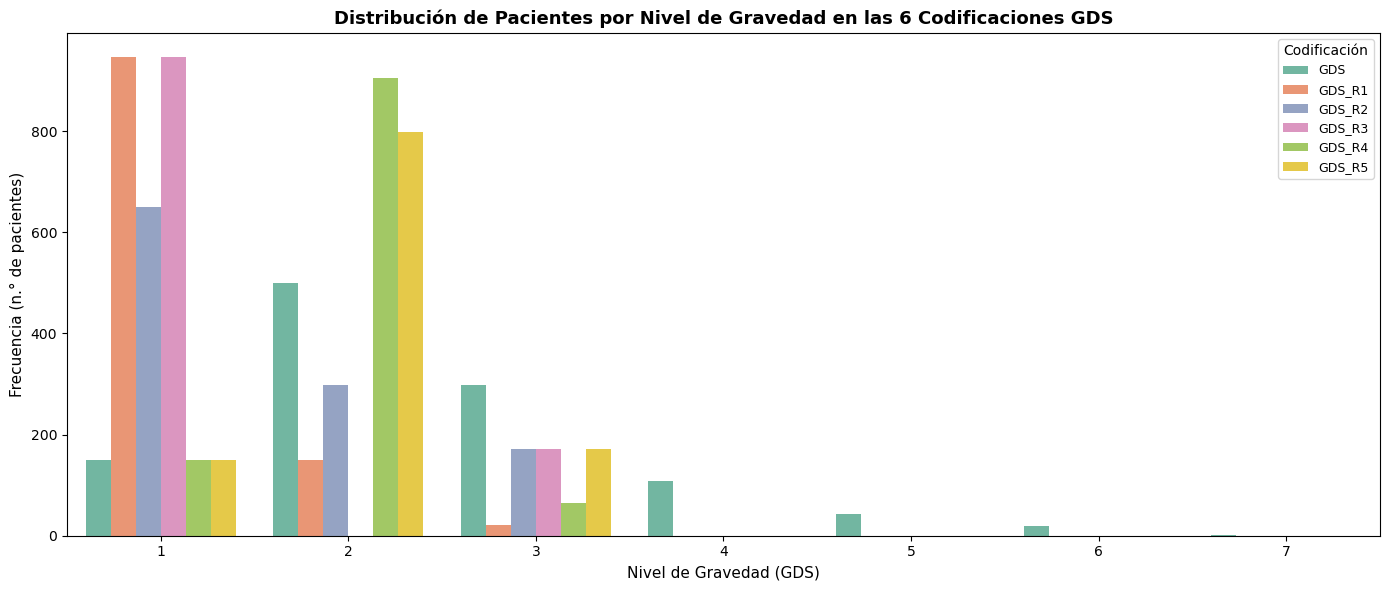

In [5]:
all_levels = sorted(df[TARGET_COLUMNS].stack().unique())

distribution_records = []
for target in TARGET_COLUMNS:
    counts = df[target].value_counts()
    for level in all_levels:
        distribution_records.append({
            'Nivel GDS': int(level),
            'Codificación': target,
            'Frecuencia': counts.get(level, 0)
        })

distribution_df = pd.DataFrame(distribution_records)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=distribution_df,
    x='Nivel GDS',
    y='Frecuencia',
    hue='Codificación',
    palette='Set2'
)
plt.title('Distribución de Pacientes por Nivel de Gravedad en las 6 Codificaciones GDS',
          fontsize=13, fontweight='bold')
plt.xlabel('Nivel de Gravedad (GDS)', fontsize=11)
plt.ylabel('Frecuencia (n.° de pacientes)', fontsize=11)
plt.legend(title='Codificación', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()

> **Interpretación — Desbalance extremo:**
>
> En todas las codificaciones se observa un **desbalance severo** de clases.
> Los niveles de gravedad bajos (clases 1 y 2) concentran la gran mayoría de los
> pacientes, mientras que los niveles más altos (clases 5, 6 y 7) representan
> fracciones marginales del conjunto de datos — en algunos casos por debajo del 1 %.
>
> Este desbalance tiene implicaciones directas sobre el modelado predictivo:
> - Un clasificador ingenuo que prediga siempre la clase mayoritaria alcanzaría
>   métricas de *accuracy* engañosamente altas sin aportar valor clínico.
> - La evaluación debe basarse en métricas robustas al desbalance
>   (*macro F1-score*, *recall* por clase, *precision* por clase).
> - Será imprescindible emplear **técnicas de remuestreo** (e.g., SMOTE) y/o
>   **métodos de ensamble** (e.g., *Bagging*, *Random Forest*, *Balanced Random Forest*)
>   que manejen adecuadamente la representación desigual de las clases.
> - Las estrategias de **validación cruzada estratificada** (o *Leave-One-Out*)
>   serán igualmente necesarias para garantizar que cada *fold* preserve la proporción
>   original de clases.

---
## 3. Selección de Características mediante χ² de Pearson (Antes de SMOTE)

Un aspecto metodológico fundamental es realizar la selección de características
**antes** de aplicar cualquier técnica de sobremuestreo (como SMOTE). Si se
seleccionaran características *después* de SMOTE, los *scores* estarían
contaminados por las instancias sintéticas, lo que produciría un ranking
artificialmente inflado y estadísticamente inválido (*data leakage*).

### Procedimiento
1. Se aíslan los **atributos predictivos** eliminando la columna `ID` y las
   seis variantes de GDS.
2. Se utiliza `SelectKBest` con `score_func=chi2` y `k='all'` para obtener el
   *score* χ² de cada atributo respecto a la variable objetivo `GDS`.
3. Se presenta un ranking ordenado y un gráfico de barras horizontales.

In [6]:
from sklearn.feature_selection import SelectKBest, chi2

NON_PREDICTIVE_COLUMNS = ['ID'] + TARGET_COLUMNS
predictive_columns = [col for col in df.columns if col not in NON_PREDICTIVE_COLUMNS]

X_original = df[predictive_columns]
y_original = df['GDS']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_original, y_original)

chi2_ranking = pd.DataFrame({
    'Atributo': predictive_columns,
    'Score χ²': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='Score χ²', ascending=False).reset_index(drop=True)

chi2_ranking.index = chi2_ranking.index + 1
chi2_ranking.index.name = 'Ranking'

print("Ranking de atributos por Score χ² (datos originales, sin SMOTE):\n")
display(chi2_ranking)

Ranking de atributos por Score χ² (datos originales, sin SMOTE):



,Atributo,Score χ²,p-value
Ranking,,,
1,A682,154.710354,7.802784e-31
2,Caldera2,139.075142,1.570778e-27
3,Imperial2,134.974549,1.150619e-26
4,Avenida2,127.966598,3.444154e-25
5,González2,121.927499,6.414141e-24
6,Copiapo2,119.187552,2.413772e-23
7,Miguel2,84.900492,3.461599e-16
8,Año,72.439148,1.290818e-13
9,Mes,48.658327,8.727032e-09


### 3.1 Gráfico de Importancia de Atributos (χ²)

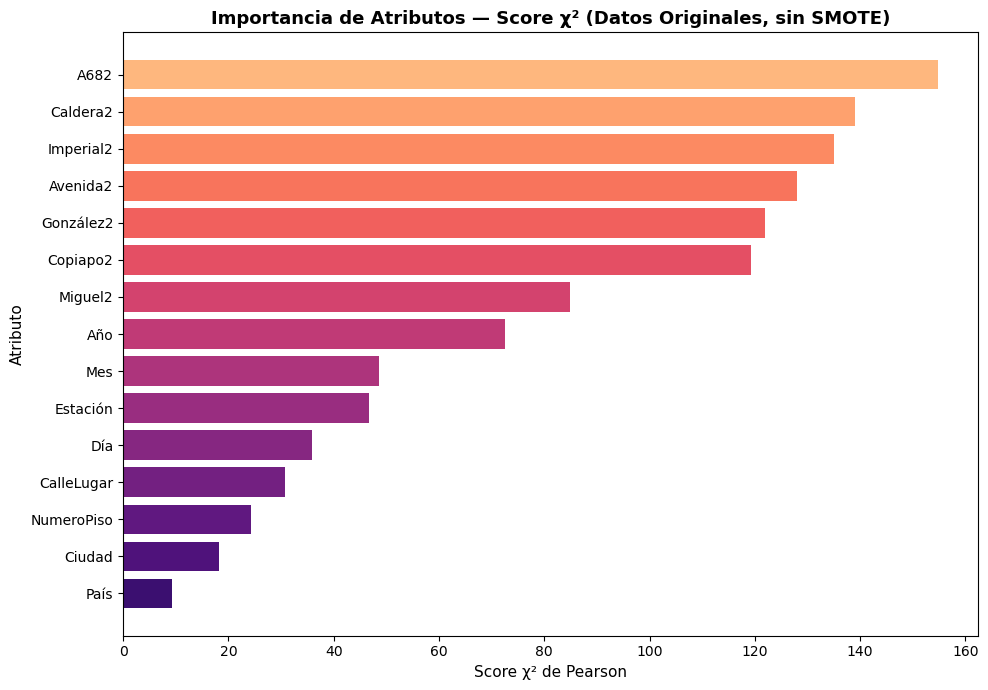

In [7]:
sorted_ranking = chi2_ranking.sort_values(by='Score χ²', ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.magma(np.linspace(0.2, 0.85, len(sorted_ranking)))
plt.barh(sorted_ranking['Atributo'], sorted_ranking['Score χ²'], color=colors)
plt.title('Importancia de Atributos — Score χ² (Datos Originales, sin SMOTE)',
          fontsize=13, fontweight='bold')
plt.xlabel('Score χ² de Pearson', fontsize=11)
plt.ylabel('Atributo', fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Top 10 de Atributos Seleccionados

In [8]:
TOP_K = 10
top_features = chi2_ranking.head(TOP_K)['Atributo'].tolist()

print(f"Las {TOP_K} variables con mayor dependencia estadística respecto a GDS son:\n")
for i, feature in enumerate(top_features, start=1):
    score = chi2_ranking.loc[chi2_ranking['Atributo'] == feature, 'Score χ²'].iloc[0]
    print(f"  {i:>2}. {feature:<15s}  (χ² = {score:.2f})")

Las 10 variables con mayor dependencia estadística respecto a GDS son:

   1. A682             (χ² = 154.71)
   2. Caldera2         (χ² = 139.08)
   3. Imperial2        (χ² = 134.97)
   4. Avenida2         (χ² = 127.97)
   5. González2        (χ² = 121.93)
   6. Copiapo2         (χ² = 119.19)
   7. Miguel2          (χ² = 84.90)
   8. Año              (χ² = 72.44)
   9. Mes              (χ² = 48.66)
  10. Estación         (χ² = 46.61)


> **Conclusión — Selección de características:**
>
> Las **10 variables** listadas anteriormente presentan los mayores valores del
> estadístico χ² de Pearson, lo que indica una **dependencia estadística clínicamente
> significativa** con el nivel de deterioro cognitivo (`GDS`).
>
> Estas variables serán las candidatas principales para la fase de modelado
> predictivo, ya que concentran la mayor capacidad discriminativa entre las
> distintas clases de la escala GDS. Al haber realizado esta selección
> **sobre los datos originales** (sin remuestreo), el ranking obtenido refleja
> fielmente la relación real entre cada atributo y la variable objetivo,
> evitando el sesgo que introduciría el sobremuestreo sintético.